In [1]:
from vv.data import CIFAR10Loader, MNISTLoader
from vv.models import Autoencoder
from vv.models.fundamental import *
from vv.utilities import get_dir
import torch

/home/computerman/Desktop/VQ-VAE/VQ-VAE-Praktikum-SS24-HD/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = "CIFAR10"

# Data

In [3]:
if data == "CIFAR10":
    data_loader = CIFAR10Loader(train_val_split=0.8,
                                batch_size=1,
                                workers=10,
                                verbose=False)
    data_size = [3, 32, 32]
elif data == "MNIST":
    data_loader = MNISTLoader(train_val_split=0.8,
                            batch_size=1,
                            workers=10,
                            verbose=False)
    data_size = [1, 28, 28]

In [4]:
data_loader.prepare_data()
data_loader.setup("predict")
data = data_loader.predict_dataloader()


sample = next(iter(data))
print(sample[0].shape)
print(sample[1].shape)

Files already downloaded and verified
Files already downloaded and verified
torch.Size([1, 3, 32, 32])
torch.Size([1])


# Model

### Base encoder

In [5]:
"""
base_encoder = LinearEncoder(input_size=data_size,
                             hidden_layer_sizes=[650, 500, 400],
                             output_size = 350,
                             dropout_prob=0.0,
                             batch_norm=True)
"""

'\nbase_encoder = LinearEncoder(input_size=data_size,\n                             hidden_layer_sizes=[650, 500, 400],\n                             output_size = 350,\n                             dropout_prob=0.0,\n                             batch_norm=True)\n'

In [6]:
"""
base_encoder = ConvolutionalEncoder(input_size=data_size,
                                    output_size = 500,
                                    channels = [3, 8, 16, 32],
                                    kernel_sizes = [3, 3, 3],
                                    strides = [1, 1, 1],
                                    pooling_sizes = [2, 2, 2],
                                    pooling_layer = "max",
                                    dropout_prob=0.0,
                                    batch_norm=True)
"""

'\nbase_encoder = ConvolutionalEncoder(input_size=data_size,\n                                    output_size = 500,\n                                    channels = [3, 8, 16, 32],\n                                    kernel_sizes = [3, 3, 3],\n                                    strides = [1, 1, 1],\n                                    pooling_sizes = [2, 2, 2],\n                                    pooling_layer = "max",\n                                    dropout_prob=0.0,\n                                    batch_norm=True)\n'

In [7]:
base_encoder = ResEncoder(input_size=data_size,
                          output_units=10,
                          dropout_prob=0.0,
                          batch_norm=True)

In [8]:
"""
base_encoder = DenseEncoder(input_size=data_size,
                            output_size=[10, 11, 11],
                            block_to_conv_ratio=5,
                            block_type="residual",
                            growth_rate=32,
                            hidden_units=20,
                            layer_per_block=5,
                            dropout_prob=0.0,
                            batch_norm=True)
"""

'\nbase_encoder = DenseEncoder(input_size=data_size,\n                            output_size=[10, 11, 11],\n                            block_to_conv_ratio=5,\n                            block_type="residual",\n                            growth_rate=32,\n                            hidden_units=20,\n                            layer_per_block=5,\n                            dropout_prob=0.0,\n                            batch_norm=True)\n'

### Encoder

In [9]:
encoder = base_encoder

In [10]:
# encoder = VariationalEncoder(base_encoder = base_encoder)

In [11]:
"""
encoder = VQEncoder(base_encoder = base_encoder,
                    attention_heads=1,
                    individual_pixel_embedding=False,
                    embedding_size=4096,
                    decoder_encoder_ste=True,
                    use_commitment_loss=True,
                    vq_loss="mse",
                    embedding_loss_weight=0.25)
"""

'\nencoder = VQEncoder(base_encoder = base_encoder,\n                    attention_heads=1,\n                    individual_pixel_embedding=False,\n                    embedding_size=4096,\n                    decoder_encoder_ste=True,\n                    use_commitment_loss=True,\n                    vq_loss="mse",\n                    embedding_loss_weight=0.25)\n'

### Decoder

In [12]:
"""
decoder = LinearDecoder(input_size = 350,
                        hidden_layer_sizes=[400, 500, 650],
                        output_size=data_size,
                        dropout_prob=0.0,
                        batch_norm=True)
"""

'\ndecoder = LinearDecoder(input_size = 350,\n                        hidden_layer_sizes=[400, 500, 650],\n                        output_size=data_size,\n                        dropout_prob=0.0,\n                        batch_norm=True)\n'

In [13]:
"""
decoder = ConvolutionalDecoder(input_size=500,
                               output_size = data_size,
                               channels = [32, 16, 8, 3],
                               kernel_sizes = [3, 3, 3],
                               strides = [1, 1, 1],
                               upsampling_sizes = [2, 2, 2],
                               dropout_prob=0.0,
                               batch_norm=True)
"""

'\ndecoder = ConvolutionalDecoder(input_size=500,\n                               output_size = data_size,\n                               channels = [32, 16, 8, 3],\n                               kernel_sizes = [3, 3, 3],\n                               strides = [1, 1, 1],\n                               upsampling_sizes = [2, 2, 2],\n                               dropout_prob=0.0,\n                               batch_norm=True)\n'

In [14]:
decoder = ResDecoder(output_size=data_size,
                     input_units=10,
                     dropout_prob=0.0,
                     batch_norm=True)

In [15]:
"""
decoder = DenseDecoder(input_size=[10, 11, 11],
                       output_size=data_size,
                       block_to_upconv_ratio=5,
                       block_type="residual",
                       growth_rate=32,
                       hidden_units=20,
                       layer_per_block=5,
                       use_upsampling=False,
                       dropout_prob=0.0,
                       batch_norm=True)
"""

'\ndecoder = DenseDecoder(input_size=[10, 11, 11],\n                       output_size=data_size,\n                       block_to_upconv_ratio=5,\n                       block_type="residual",\n                       growth_rate=32,\n                       hidden_units=20,\n                       layer_per_block=5,\n                       use_upsampling=False,\n                       dropout_prob=0.0,\n                       batch_norm=True)\n'

### Full model

In [25]:
checkpoint_path = get_dir("models",
                          "TEST",
                          "version_6",
                          "checkpoints",
                          "epoch=29-val_loss=0.00.ckpt")

model = Autoencoder.load_from_checkpoint(checkpoint_path=checkpoint_path,
                                         encoder=encoder,
                                         decoder=decoder,
                                         latent_error_weight=0.00,
                                         learning_rate=1e-3,
                                         lr_patience=10,
                                         check_val_every_n_epoch=5)

# Plotting and predicting results

In [18]:
import random

def get_random_sample(dataset):
    # Convert the DataLoader to an iterator
    data_iter = iter(dataset)

    # Get the number of batches
    num_batches = len(dataset)

    # Randomly select a batch index
    batch_idx = random.randint(0, num_batches - 1)

    # Get the batch at the selected index
    for _ in range(batch_idx + 1):
        batch = next(data_iter)

    return batch[0], batch[1], batch_idx

def get_sample_of_number(dataset, batch_idx):
    # Convert the DataLoader to an iterator
    data_iter = iter(dataset)

    # Get the batch at the selected index
    for _ in range(batch_idx + 1):
        batch = next(data_iter)


    return batch[0], batch[1], batch_idx

In [19]:
import matplotlib.pyplot as plt

def draw_images(input, output):
    # Adjust the tensors to [0, 1] range
    input = (input + 1) / 2
    output = (output + 1) / 2
    
    # Display the sample image
    plt.subplot(1, 2, 1)
    plt.imshow(input[0].permute(1, 2, 0))
    plt.title('Sample Image')
    plt.axis('off')

    # Display the output image
    plt.subplot(1, 2, 2)
    plt.imshow(output[0].detach().permute(1, 2, 0))
    plt.title('Output Image')
    plt.axis('off')

    plt.show()

def draw_image(img, model_num):
    # Adjust the tensors to [0, 1] range
    img = (img + 1) / 2
    
    # Display the sample image
    plt.imshow(img[0].detach().permute(1, 2, 0))
    plt.axis('off')

    plt.savefig(f"../plots/img_quality_comparison/model_{model_num}.png")
    plt.show()

In [20]:
def compare_images(model, data, batch_num):
    sample, label, sample_num = get_sample_of_number(data, batch_num)
    original_image = sample
    model.to("cpu")
    sample.to("cpu")
    model.eval()
    reconstructed_image = model.forward(sample)
    print("Image number: ", sample_num)
    print("Label: ", label)
    # print("Original Image: ", original_image)
    # print("Reconstructed Image: ", reconstructed_image)
    draw_images(original_image, reconstructed_image)

Comparing images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Image number:  9
Label:  tensor([1])


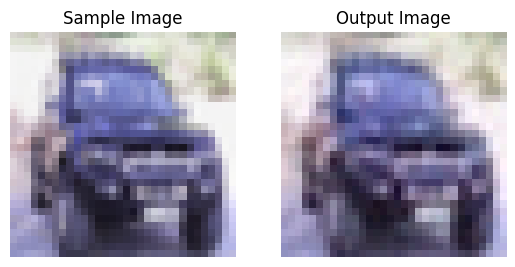

In [21]:
compare_images(model, data, 9)

# Sampling from the model

In [22]:
def sample_model(model, n_smaples):
    model.eval()
    model.to("cpu")
    latent_size = model.encoder.output_size
    with torch.no_grad():
        samples = model.sample(n_samples=n_smaples)

    return samples

In [23]:
def draw_image(sample):
    # Adjust the tensors to [0, 1] range
    sample = (sample + 1) / 2
    
    # Display the sample image
    plt.imshow(sample[0].permute(1, 2, 0))
    plt.title('Sample Image')
    plt.axis('off')

    plt.show()

In [24]:
sample = sample_model(model, 1)
draw_image(sample)

AttributeError: Encoder does not have a sample method.